In [1]:
import csv
import pandas as pd

### Import data and reformat

In [2]:
asv_16S = pd.read_csv("Merged2018_16S_otu_filtered.csv")
asv_18S = pd.read_csv("Merged2018_18S_otu_filtered.csv")
meta = pd.read_csv("Merged2018_meta_filtered.csv")
tax_16S = pd.read_csv("Merged2018_16S_taxa_filtered.csv")
tax_18S = pd.read_csv("Merged2018_18S_taxa_filtered.csv")

In [3]:
asv_16S = asv_16S.rename(columns = {'Unnamed: 0' : 'ASV'}).set_index('ASV')
asv_18S = asv_18S.rename(columns = {'Unnamed: 0' : 'ASV'}).set_index('ASV')
tax_16S = tax_16S.rename(columns = {'Unnamed: 0' : 'ASV'})
tax_18S = tax_18S.rename(columns = {'Unnamed: 0' : 'ASV'})
tax_18S.head()

,ASV,Kingdom,Phylum,Class,Order,Family,Genus,Species
0,ASV_1,Eukaryota,Arthropoda,Hexanauplia,Calanoida,Calanidae,unassigned,unassigned
1,ASV_2,Eukaryota,Arthropoda,Hexanauplia,Calanoida,Metridinidae,Metridia,unassigned
2,ASV_3,Eukaryota,Arthropoda,Hexanauplia,Calanoida,Paracalanidae,Paracalanus,unassigned
3,ASV_4,Eukaryota,unknown,Dinophyceae,Thoracosphaerales,Thoracosphaeraceae,Ensiculifera,Ensiculifera imariensis
4,ASV_5,Eukaryota,unknown,Dinophyceae,unassigned,unassigned,unassigned,unassigned


#### subset ASV tables and metadata by cruise

In [4]:
meta_Lasker = meta[meta['cruise'] == 'Lasker'].rename(columns = {'sample_name' : '#SampleID'}).set_index('#SampleID')
meta_CN18S = meta[meta['cruise'] == 'CN18S'].rename(columns = {'sample_name' : '#SampleID'}).set_index('#SampleID')
meta_CN18F = meta[meta['cruise'] == 'CN18F'].rename(columns = {'sample_name' : '#SampleID'}).set_index('#SampleID')
meta_CN18F.head()

,Dataset,project_name,vessel,ESP_sample_match,year,season,collection_date_Flyer,sampling_platform,sampling_device,filtration_device,...,F_primer,R_primer,primers_FR,seq_platform,seq_model,seq_chemistry,run_center,run_date,Description,cruise
#SampleID,,,,,,,,,,,,,,,,,,,,,
CN18Fc51_5_eDNA,Merged2018,eCruises_2018,Flyer,CN18FESPkoa_SC24,2018,Fall,20180911,Flyer,CTD,peristaltic,...,515F (Parada),806R (Apprill),515F_806R,Illumina,MiSeq,2x150bp PE,Laragen,July_2019,Spring and fall 2018 Flyer cruise and paired E...,CN18F
CN18FESPkoa_SC24,Merged2018,eCruises_2018,Tethys,CN18Fc51_5_eDNA,2018,Fall,20180911,Tethys,AUV,ESP,...,515F (Parada),806R (Apprill),515F_806R,Illumina,MiSeq,2x150bp PE,Laragen,July_2019,Spring and fall 2018 Flyer cruise and paired E...,CN18F
CN18FESPkoa_SC29,Merged2018,eCruises_2018,Tethys,CN18Fc47_6_eDNA,2018,Fall,20180910,Tethys,AUV,ESP,...,515F (Parada),806R (Apprill),515F_806R,Illumina,MiSeq,2x150bp PE,Laragen,July_2019,Spring and fall 2018 Flyer cruise and paired E...,CN18F
CN18Fc47_6_eDNA,Merged2018,eCruises_2018,Flyer,CN18FESPkoa_SC29,2018,Fall,20180910,Flyer,CTD,peristaltic,...,515F (Parada),806R (Apprill),515F_806R,Illumina,MiSeq,2x150bp PE,Laragen,July_2019,Spring and fall 2018 Flyer cruise and paired E...,CN18F
CN18FESPkoa_SC26,Merged2018,eCruises_2018,Tethys,CN18Fc49_6_eDNA,2018,Fall,20180911,Tethys,AUV,ESP,...,515F (Parada),806R (Apprill),515F_806R,Illumina,MiSeq,2x150bp PE,Laragen,July_2019,Spring and fall 2018 Flyer cruise and paired E...,CN18F


In [6]:
asv_16S_Lasker = asv_16S[meta_Lasker.index]
asv_18S_Lasker = asv_18S[meta_Lasker.index]
asv_16S_CN18S = asv_16S[meta_CN18S.index]
asv_18S_CN18S = asv_18S[meta_CN18S.index]
asv_16S_CN18F = asv_16S[meta_CN18F.index]
asv_18S_CN18F = asv_18S[meta_CN18F.index]

In [7]:
tax_16S_Lasker = tax_16S[tax_16S['ASV'] == asv_16S_Lasker.index].set_index('ASV')
tax_18S_Lasker = tax_18S[tax_18S['ASV'] == asv_18S_Lasker.index].set_index('ASV')
tax_16S_CN18S = tax_16S[tax_16S['ASV'] == asv_16S_CN18S.index].set_index('ASV')
tax_18S_CN18S = tax_18S[tax_18S['ASV'] == asv_18S_CN18S.index].set_index('ASV')
tax_16S_CN18F = tax_16S[tax_16S['ASV'] == asv_16S_CN18F.index].set_index('ASV')
tax_18S_CN18F = tax_18S[tax_18S['ASV'] == asv_18S_CN18F.index].set_index('ASV')

#### Format taxonomy files for BIOM

In [8]:
tax_16S_Lasker_str = tax_16S_Lasker.apply(lambda row: '; '.join(row.dropna().astype(str)), axis=1)
tax_18S_Lasker_str = tax_18S_Lasker.apply(lambda row: '; '.join(row.dropna().astype(str)), axis=1)
tax_16S_CN18S_str = tax_16S_CN18S.apply(lambda row: '; '.join(row.dropna().astype(str)), axis=1)
tax_18S_CN18S_str = tax_18S_CN18S.apply(lambda row: '; '.join(row.dropna().astype(str)), axis=1)
tax_16S_CN18F_str = tax_16S_CN18F.apply(lambda row: '; '.join(row.dropna().astype(str)), axis=1)
tax_18S_CN18F_str = tax_18S_CN18F.apply(lambda row: '; '.join(row.dropna().astype(str)), axis=1)

In [9]:
from biom.table import Table
from gemelli.rpca import rpca
#import numpy as np

#### Make BIOM tables

In [10]:
asv_16S_Lasker_biom = Table(asv_16S_Lasker.values, list(asv_16S_Lasker.index), list(asv_16S_Lasker.columns), 
                            observation_metadata = [{'taxonomy': t.split('; ')} for t in tax_16S_Lasker_str.loc[asv_16S_Lasker.index]])
asv_18S_Lasker_biom = Table(asv_18S_Lasker.values, list(asv_18S_Lasker.index), list(asv_18S_Lasker.columns), 
                            observation_metadata = [{'taxonomy': t.split('; ')} for t in tax_18S_Lasker_str.loc[asv_18S_Lasker.index]])
asv_16S_CN18S_biom = Table(asv_16S_CN18S.values, list(asv_16S_CN18S.index), list(asv_16S_CN18S.columns), 
                            observation_metadata = [{'taxonomy': t.split('; ')} for t in tax_16S_CN18S_str.loc[asv_16S_CN18S.index]])
asv_18S_CN18S_biom = Table(asv_18S_CN18S.values, list(asv_18S_CN18S.index), list(asv_18S_CN18S.columns), 
                            observation_metadata = [{'taxonomy': t.split('; ')} for t in tax_18S_CN18S_str.loc[asv_18S_CN18S.index]])
asv_16S_CN18F_biom = Table(asv_16S_CN18F.values, list(asv_16S_CN18F.index), list(asv_16S_CN18F.columns), 
                            observation_metadata = [{'taxonomy': t.split('; ')} for t in tax_16S_CN18F_str.loc[asv_16S_CN18F.index]])
asv_18S_CN18F_biom = Table(asv_18S_CN18F.values, list(asv_18S_CN18F.index), list(asv_18S_CN18F.columns), 
                            observation_metadata = [{'taxonomy': t.split('; ')} for t in tax_18S_CN18F_str.loc[asv_18S_CN18F.index]])

Using table.biom in [biom format](http://biom-format.org/), a raw count table, we will generate our beta diversity ordination file. There are a few parameters to gemelli that we may want to consider. The first is filtering cutoffs, these are `min-feature-count`, `min-sample-count`, and `min-feature-frequency`. Both min-feature-count and min-sample-count accept integer values and remove feature or samples, respectively, with sums below this cutoff. The feature cut-off is useful in the case that features with very low total counts among all samples represent contamination or chimeric sequences. The sample cut off is useful for the case that some sample received very few reads relative to other samples. The min-feature-frequency can be useful to remove features that only appear in a small portion of samples, which may be difficult to further asses using tools like [Qurro](https://github.com/biocore/qurro).

**Note:** it is _not_ recommended to bin your features by taxonomic assignment (i.e. by genus level). 
**Note:** it is _not_ recommended to rarefy your data before using gemelli. 

The other main parameter of the gemelli is the number of components to use through `n-components` (i.e. the rank). gemelli relies on a low-rank assumption and therefore it is recommended to choose a value between 2 and 10. 

Now that we understand the acceptable parameters, we are ready to run gemelli.  


The same command can be run using the python API through the following:

In [12]:
import skbio

In [13]:
skbio.__version__

'0.6.2'

In [16]:
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

## Biplot helper function

In [45]:
def biplot(axis1, axis2, sload, fload, hue, ax,
           n_arrow= 15, level=2, cmap = 'Set1'):
    
    """
    This function is a helper for the tutorial. It
    takes ordination inputs from the tutorial and
    plots a compositional biplot.
    
    Parameters
    ----------
    axis1: str - first x-PC axis

    axis2: str - second y-PC axis
    
    sload: pd.DataFrame - sample ordination

    fload: pd.DataFrame - feature ordination

    hue: str - subject groupings
        
    ax: matplitlib subplot

    n_arrow: int - number of arrows to plot

    level: int - taxonomic level to collapse

    Returns
    ----------
    ax: matplitlib subplot

    """

    # sort the arrows by their PC1, PC2 mag.
    fload['magnitude'] = np.linalg.norm(fload[[axis1, axis2]], axis=1)
    fload = fload.sort_values('magnitude', ascending=False)
    
    # get a taxonomic level split
    def _collapse(tax, max_observed_level = 7):
        tax = [x.strip() for x in tax.split(';')]
        if len(tax) < max_observed_level:
            padding = ['__'] * (max_observed_level - len(tax))
            tax.extend(padding)
        return ';'.join(tax[:level])
    fload['level'] = fload.Taxon.apply(_collapse)
    
    # get cmap for arrows
    arrow_cmap = set(fload.loc[fload.index[: n_arrow], 'level'].values)
    colors_ = plt.get_cmap(cmap, len(arrow_cmap))
    arrow_cmap = {v:colors_(i) for i, v in enumerate(arrow_cmap)}

    # plot the sample loadings
    sns.scatterplot(data = sload, x=axis1, y=axis2,
                    hue = hue,
                    palette=cmap,
                    ax=ax)
    # plot the arrows
    legend_arrows = {}
    for i in range(n_arrow):
         add arrow
        ind_ = fload.index[i]
        arrow_  = ax.arrow(0, 0, fload.loc[ind_, axis1],
                        fload.loc[ind_, axis2],
                        color=arrow_cmap[fload.loc[ind_, 'level']],
                        width=0.001, head_width=0.005)
        legend_arrows[fload.loc[ind_, 'level']] = arrow_
    
    # add legend
    leg1 = ax.legend(loc='center left',
                     bbox_to_anchor=(1, .8),
                     title="Depth (m)")
    ax.legend(list(legend_arrows.values()),
              list(legend_arrows.keys()), 
              loc='center left',
              bbox_to_anchor=(1, 0.5),
              title="feature legend (arrows)")
    ax.add_artist(leg1)
        
    return ax

In [144]:
#from skbio import diversity
from gemelli.rpca import rpca

# perform RPCA
ordination, distance = rpca(asv_18S_Lasker_biom, min_sample_count=2)

We can view the ordination loadings through the `ordination` result of type OrdinationResults.

In [145]:
# the sample loadings
spca_df = ordination.samples
spca_df.head(2)

,PC1,PC2,PC3
Lasker18Sc124_17,-0.031941,-0.200132,-0.075568
Lasker18Sc124_19,-0.045825,-0.189975,-0.041023


In [146]:
# the feature loadings
fpca_df = ordination.features
fpca_df.head(2)

,PC1,PC2,PC3
ASV_1,-0.055546,0.002547,0.135599
ASV_2,0.034875,0.010644,0.051587


Next we can directly add the metadata to the loadings.

In [147]:
# merge the sample metadata and loadings
spca_df = pd.concat([spca_df, meta_Lasker.reindex(spca_df.index)],
                    axis=1, sort=True)
spca_df.head(2)

,PC1,PC2,PC3,Dataset,project_name,vessel,ESP_sample_match,year,season,collection_date_Flyer,...,F_primer,R_primer,primers_FR,seq_platform,seq_model,seq_chemistry,run_center,run_date,Description,cruise
Lasker18Sc122_17,-0.008815,-0.157070,0.092209,Merged2018,eCruises_2018,Lasker,Lasker18Sc122_17_D0057,2018,Spring,20180603,...,515F (Parada),806R (Apprill),515F_806R,Illumina,MiSeq,2X250bp PE,MSU,Jan_2022,RREAS 2018,Lasker
Lasker18Sc122_19,-0.029171,-0.157419,0.050854,Merged2018,eCruises_2018,Lasker,Lasker18Sc122_19_D0058,2018,Spring,20180603,...,515F (Parada),806R (Apprill),515F_806R,Illumina,MiSeq,2X250bp PE,MSU,Jan_2022,RREAS 2018,Lasker


In [148]:
# merge the feature metadata and loadings
fpca_df = pd.concat([fpca_df, tax_18S.set_index('ASV')],
                    axis=1, sort=True)
fpca_df['Taxon'] = tax_18S_Lasker_str
fpca_df.head(2)

,PC1,PC2,PC3,Kingdom,Phylum,Class,Order,Family,Genus,Species,Taxon
ASV_1,-0.055546,0.002547,0.135599,Eukaryota,Arthropoda,Hexanauplia,Calanoida,Calanidae,unassigned,unassigned,Eukaryota; Arthropoda; Hexanauplia; Calanoida;...
ASV_10,0.099141,-0.020466,0.091871,Eukaryota,unknown,unknown,unknown,unknown,unknown,Acantharian sp. 6201,Eukaryota; unknown; unknown; unknown; unknown;...


Now we will plot both loadings as a biplot by using seaborn and matplotlib. To do this we will first make a plotting helper function called `biplot` which is located in the assets directory.

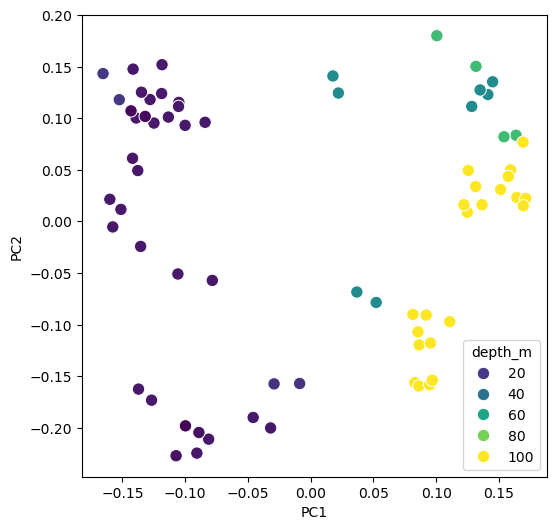

In [149]:
fig, ax = plt.subplots(1,1, figsize=(6, 6))

cmap = sns.color_palette("viridis", as_cmap=True)

pca = sns.scatterplot(data=spca_df, x='PC1', y='PC2', 
                     hue='depth_m', s=80, palette=cmap, ax=ax)

figure = pca.get_figure()    
figure.savefig('PCA_Lasker_18S_depth_gemelli.png', dpi=400)

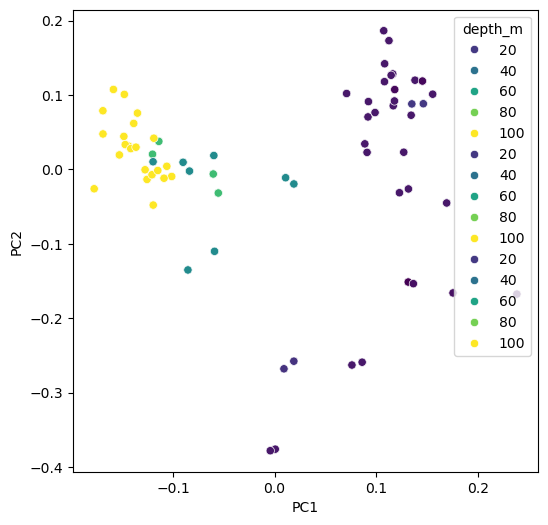

In [66]:
figure

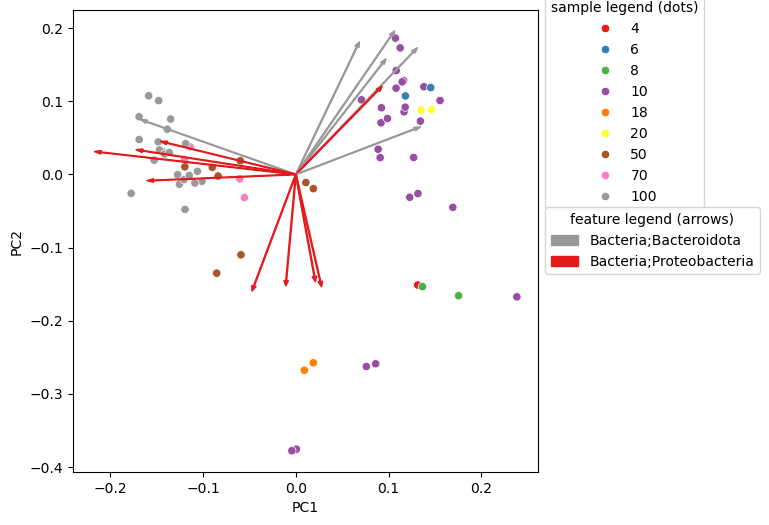

In [46]:
fig, ax = plt.subplots(1,1, figsize=(6, 6))

# plot the biplot
ax = biplot('PC1', 'PC2', sload = spca_df,
            fload = fpca_df, hue = 'depth_m'\)

plt.show()

Biplots are exploratory visualization tools that allow us to represent the features (i.e. taxonomy or OTUs)  that strongly influence the principal component axis as arrows. The interpretation of the compositional biplot differs slightly from classical biplot interpretation. The important features with regard to sample clusters are not a single arrow but by the log ratio between features represented by arrows pointing in different directions.


In [11]:
from skbio.stats.distance import permanova

permanova(distance, mf['BodySite'])

method name               PERMANOVA
test statistic name        pseudo-F
sample size                      34
number of groups                  4
test statistic              1.67627
p-value                       0.057
number of permutations          999
Name: PERMANOVA results, dtype: object

Indeed we can now see that the clusters we saw in the biplot are significant.

We can see from the biplot and PERMANOVA results that gut is very different from the skin samples. Next we can use [qurro](https://github.com/biocore/qurro) to explore log-ratios of the microbes highlighted by gemelli. For more about why log-ratios are useful you may want to read ["Establishing microbial composition measurement standards with reference frames"](https://www.nature.com/articles/s41467-019-10656-5).

A tsv file with the log-ratios can be exported and a t-test by BodySite on the log-ratios could confirm this observation by using the `Export current sample plot data` button. 

In [13]:
import itertools
from scipy.stats import ttest_ind

# import the taxonomy metadata
lrdf = pd.read_csv('qiime2-moving-pictures-tutorial/sample_plot_data.tsv',
                   sep='\t', index_col=0).dropna(subset=['Current_Natural_Log_Ratio'])
# split data by BodySite
lrs = {type_:df_.Current_Natural_Log_Ratio
       for type_, df_ in lrdf.groupby('BodySite')}
# get all combos
ids_ = list(itertools.combinations(lrs.keys(), 2))
# take t-test
tst = pd.DataFrame({(id1_, id2_):ttest_ind(lrs[id1_], lrs[id2_])
                    for id1_, id2_ in ids_},
                   ['test-stat','p-value']).T
tst.index.names = ['group one vs.', 'group two']
# view results
tst


test-stat       p-value
group one vs. group two                          
gut           left palm    9.943842  3.749890e-06
              right palm   3.385889  6.933597e-03
              tongue      20.744948  6.574794e-09
left palm     right palm  -1.181070  2.587322e-01
              tongue       1.526182  1.528810e-01
right palm    tongue       1.893318  8.078723e-02

From this we can see that gut vs. skin and oral is significantly different using this log-ratio but skin vs. oral is not.